# Tuned Support Vector Regression Model
## T2 Immunological Data
### Target: pain_reduction_pct

In [1]:
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import model_svr
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'

# Path to save results
MODEL_DIR = os.path.abspath('../models/pain-reduction')

In [2]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)

# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_outlier_observations(df_cl_mod, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)


In [3]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_scale_red = model.construct_datasets_targets(df_cl_mod, 'pain_scale', [1, 2])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_scale_red, timepoints=[2])

pt = PowerTransformer(method='yeo-johnson', standardize=True)


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.382  std=2.061  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.720  std=33.059  [-100.000, 87.654]

Constructing datasets for modeling:

Modeling dataset ready: T2 features + clinical features
Shape: (129, 95),  Patients: 129


## SVR Model + MRMR Feature Selection
### + Optuna Hyperparameter Tuning

In [4]:
importlib.reload(model_svr)
svr_results, svr_feature_freq, svr_per_fold  = model_svr.svr_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

joblib.dump(svr_feature_freq, os.path.join(MODEL_DIR, 'svr_feature_freq.pkl'))
joblib.dump(svr_per_fold, os.path.join(MODEL_DIR, 'svr_per_fold.pkl'))


 Nested CV - SVR + MRMR + Optuna — pain_reduction_pct
  n=129, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    MRMR Trial  1/20: RMSE=1.2238  {'K': 15, 'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 14}
    MRMR Trial  2/20: RMSE=1.2222  {'K': 20, 'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 13}
    MRMR Trial  3/20: RMSE=1.1615  {'K': 20, 'n_estimators': 400, 'max_depth': 7, 'min_samples_leaf': 8}
    MRMR Trial  4/20: RMSE=1.1944  {'K': 15, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 17}
    MRMR Trial  5/20: RMSE=1.1574  {'K': 20, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 9}
    MRMR Trial  6/20: RMSE=1.2053  {'K': 10, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 19}
    MRMR Trial  7/20: RMSE=1.2022  {'K': 15, 'n_estimators': 400, '

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\svr_per_fold.pkl']

### Plot of Feature Frequency List
Top 25 selections shown in plot.

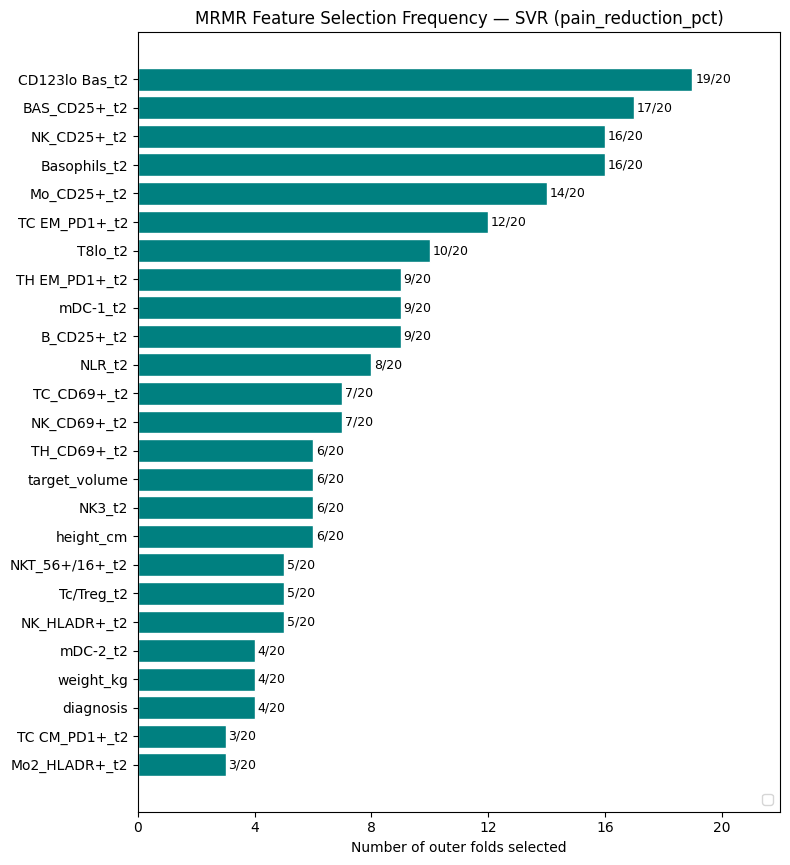

In [5]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'svr_feature_freq.pkl'))
model.plot_feature_frequency(feature_list, name='SVR (pain_reduction_pct)', top=25)

## Jaccard Index of Selected Features
### Pariwise Comparisons for Each Outer Fold (20x20)


  Jaccard Scores — SVR (MRMR Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.266 ± 0.111
  Min  Jaccard : 0.034
  Max  Jaccard : 0.538


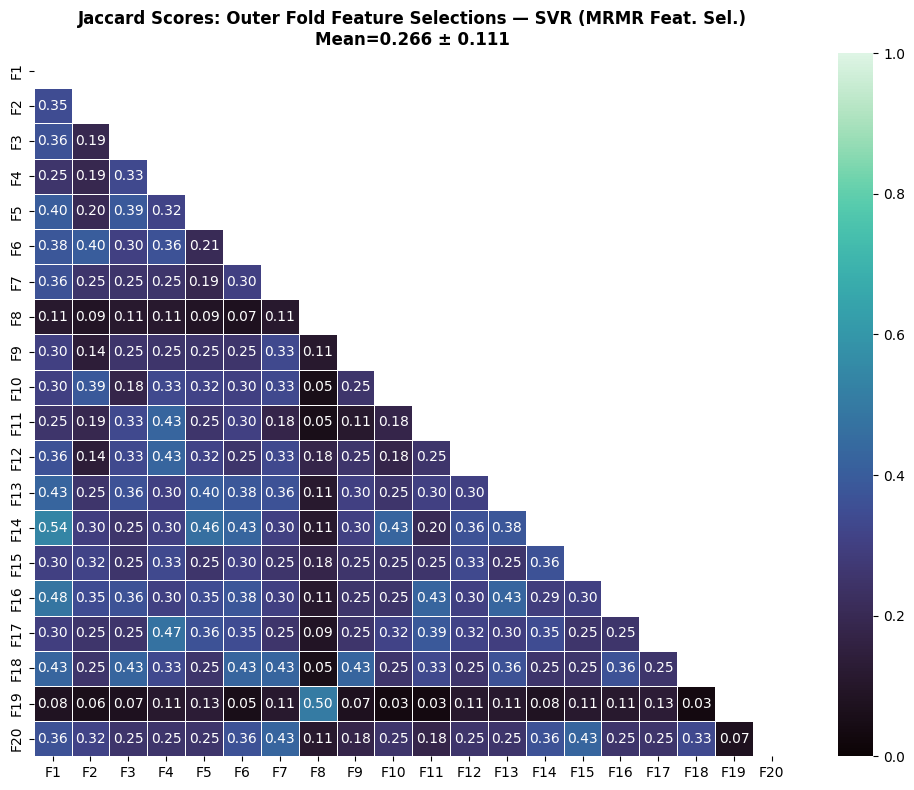

In [12]:
selected_per_fold = joblib.load(os.path.join(MODEL_DIR, 'svr_per_fold.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold, name='SVR (MRMR Feat. Sel.)')

## SVR on different subsets of selected features

In [7]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'svr_feature_freq.pkl'))
importlib.reload(model_svr)
svr_sweep_df = model_svr.svr_threshold_analysis(
     df_pain, 
     feature_list, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(svr_sweep_df,      os.path.join(MODEL_DIR, 'svr_sweep_df.pkl'))


  Threshold  all ( ):  94 features
  ['CD123lo Bas_t2', 'BAS_CD25+_t2', 'NK_CD25+_t2', 'Basophils_t2', 'Mo_CD25+_t2', 'TC EM_PD1+_t2', 'T8lo_t2', 'TH EM_PD1+_t2']...
  Outer Fold  1/20:  Best Trial 25/50  RMSE=0.9953  {'C': 0.25052661321962194, 'epsilon': 0.011501147510421113, 'gamma': 0.03803727686443849}
  Outer Fold  2/20:  Best Trial 46/50  RMSE=0.9982  {'C': 0.010311937372542532, 'epsilon': 0.03282877800957409, 'gamma': 0.8642096374754428}
  Outer Fold  3/20:  Best Trial  3/50  RMSE=0.9992  {'C': 0.017073967431528128, 'epsilon': 0.39676050770529875, 'gamma': 0.2537815508265665}
  Outer Fold  4/20:  Best Trial 41/50  RMSE=0.9979  {'C': 0.7900431329414052, 'epsilon': 0.0016459045010490158, 'gamma': 0.0053577011823440004}
  Outer Fold  5/20:  Best Trial 42/50  RMSE=1.0064  {'C': 0.07397209495538974, 'epsilon': 0.7266743335143618, 'gamma': 0.7218212012430643}
  Outer Fold  6/20:  Best Trial 45/50  RMSE=0.9968  {'C': 0.023631193075628634, 'epsilon': 0.6927910685657055, 'gamma': 0.9757

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\svr_sweep_df.pkl']

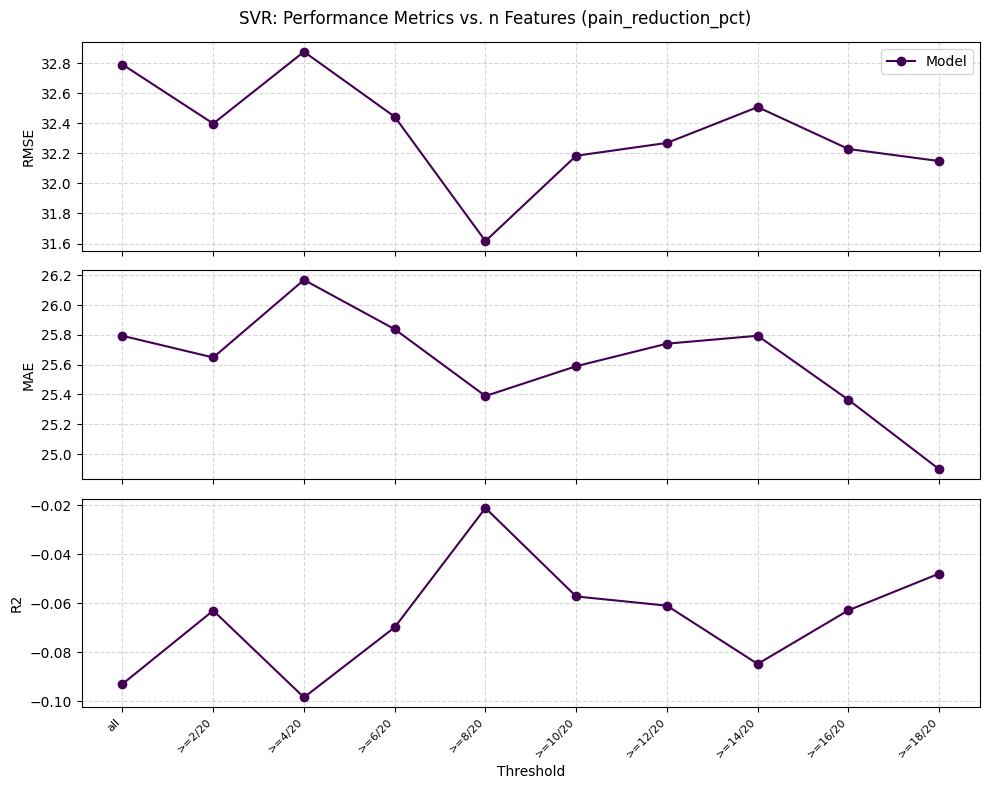

In [8]:
# plot sweep
# Plot performances on different feature-tresholds
importlib.reload(model)
model.plot_sweep(svr_sweep_df, title='SVR: Performance Metrics vs. n Features (pain_reduction_pct)')

# Final SVR Model
## Features Selected in >= 8/20 outer folds: 11 features

In [4]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'svr_feature_freq.pkl'))
sel_features = feature_list[feature_list >= 8].index.tolist()

results_svr, svr_model, svr_X_final, svr_y_pred, svr_patient_err, svr_err_df, svr_scaler, svr_errors = model_svr.run_tuned_svr(
    df_pain, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(results_svr,               os.path.join(MODEL_DIR, 'svr_results.pkl'))
joblib.dump(svr_model,                os.path.join(MODEL_DIR, 'svr_model.pkl'))
joblib.dump(svr_X_final,              os.path.join(MODEL_DIR, 'svr_X_final.pkl'))
joblib.dump(svr_patient_err,          os.path.join(MODEL_DIR, 'svr_patient_err.pkl'))
joblib.dump(svr_err_df,               os.path.join(MODEL_DIR, 'svr_err_df.pkl'))
joblib.dump(svr_scaler,               os.path.join(MODEL_DIR, 'svr_scaler.pkl'))
joblib.dump(svr_errors,               os.path.join(MODEL_DIR, 'svr_errors.pkl'))


  SVR (RBF) + Optuna — pain_reduction_pct
  n=129, p=11
  Outer 4×5=20 | Inner 4×5=20 | Optuna trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=0.9914  {'C': 0.31489116479568624, 'epsilon': 0.711447600934342, 'gamma': 0.8471801418819978}
    Trial   2/50: RMSE=0.9723  {'C': 2.481040974867813, 'epsilon': 0.0029380279387035343, 'gamma': 0.004207053950287938}
    Trial   3/50: RMSE=1.0089  {'C': 0.017073967431528128, 'epsilon': 0.39676050770529875, 'gamma': 0.2537815508265665}
    Trial   4/50: RMSE=0.9978  {'C': 6.79657809075816, 'epsilon': 0.00115279871282324, 'gamma': 7.579479953348009}
    Trial   5/50: RMSE=0.9983  {'C': 21.368329072358772, 'epsilon': 0.004335281794951566, 'gamma': 0.005337032762603957}
    Trial   6/50: RMSE=0.9708  {'C': 0.05415244119402541, 'epsilon': 0.008179499475211672, 'gamma': 0.12561043700013558}
    Trial   7/50: RMSE=0.938

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\svr_errors.pkl']

## Difficult Patient Predictions

In [10]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'svr_patient_err.pkl'))
print(patient_err.to_string())

         mean_mae  n_folds
Patient                   
248         99.67        5
145         80.26        5
72          64.48        5
171         61.24        5
181         60.77        5
105         58.48        5
240         55.28        5
203         54.31        5
207         53.17        5
258         52.35        5
215         52.13        5
118         51.04        5
230         50.17        5
76          49.81        5
114         49.43        5
256         48.49        5
127         47.16        5
129         45.94        5
113         44.38        5
195         44.31        5
109         42.77        5
132         42.05        5
17          40.23        5
144         40.09        5
112         39.87        5
1           39.85        5
161         38.80        5
196         38.14        5
239         38.05        5
205         37.98        5
137         37.91        5
123         37.59        5
201         36.82        5
189         36.73        5
186         35.40        5
2

## SHAP-value Plot


=== SHAP Analysis: SVR ===


  0%|          | 0/129 [00:00<?, ?it/s]

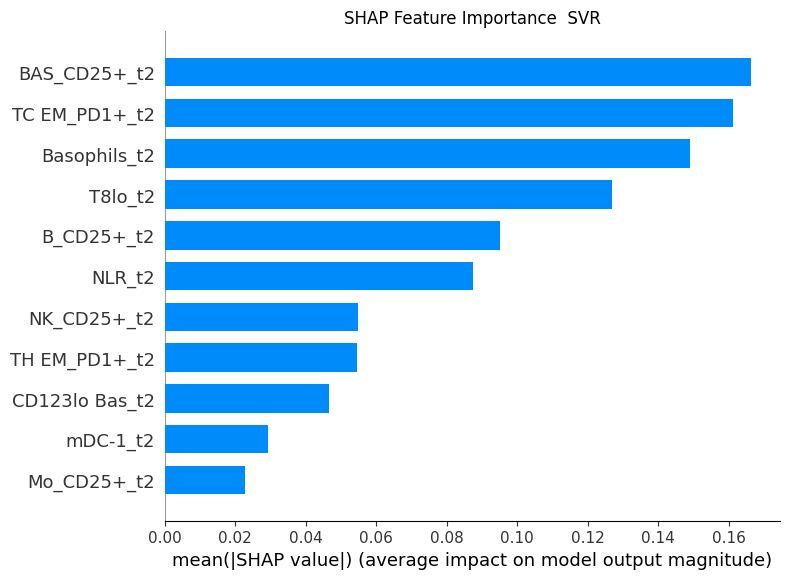

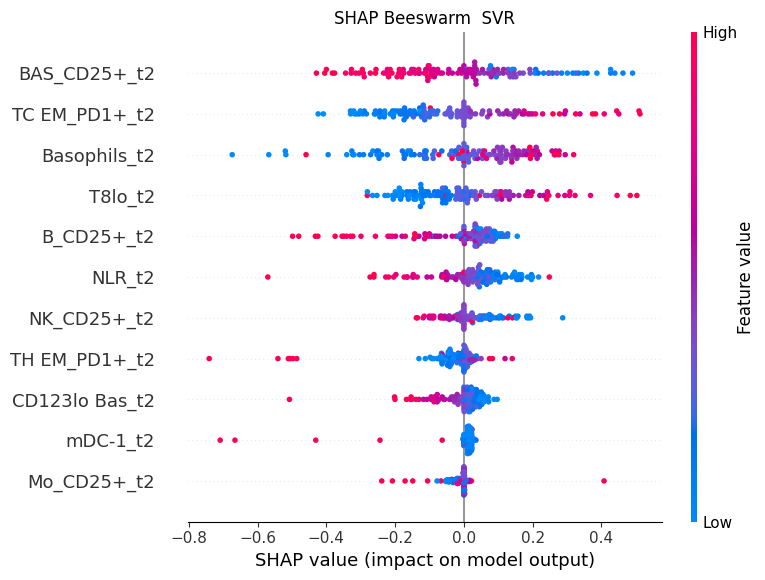

In [11]:
# Plot Shap values
svr_model= joblib.load(os.path.join(MODEL_DIR, 'svr_model.pkl'))
svr_X_final = joblib.load(os.path.join(MODEL_DIR, 'svr_X_final.pkl'))
svr_scaler = joblib.load(os.path.join(MODEL_DIR, 'svr_scaler.pkl'))

svr_shap = model.plot_shap_svr(svr_model, svr_X_final, svr_scaler)